In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, MultiHeadAttention, LayerNormalization, Dropout, Conv1D, GlobalAveragePooling1D, Add
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [11]:
df = pd.read_excel('NGC-13Vs.xlsx', sheet_name='All Vs')
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

In [12]:
df.head()

,Petroleum,Bioenergy&Waste,Nuclear,Renewables (wind,GDP,Pop,Temp,Rainfall,WinsSpeed,DailySunHours,EnergyInt,RP-Gas,RP-Elec,Natural Gas
Month,,,,,,,,,,,,,,
1995-01-01,6.16,0.14,1.51,0.0,5610,57.955000,4.9,NaN,NaN,NaN,5.0,58.9,86.5,8.90
1995-02-01,6.32,0.14,1.59,0.0,5610,57.966633,6.7,NaN,NaN,NaN,5.0,59.1,86.3,7.16
1995-03-01,6.96,0.14,1.91,0.0,5610,57.978267,5.6,NaN,NaN,NaN,5.0,59.5,86.3,7.91
1995-04-01,6.08,0.14,1.78,0.0,5613,57.989900,8.9,NaN,NaN,NaN,5.0,59.2,85.6,5.75
1995-05-01,6.23,0.14,1.55,0.0,5613,58.001533,11.6,NaN,NaN,NaN,5.0,59.2,85.4,4.79


In [13]:
df['Month_Num'] = df.index.month

missing_cols = ['Rainfall', 'WinsSpeed', 'DailySunHours']
monthly_means = df.groupby('Month_Num')[missing_cols].mean()

for col in missing_cols:
    df[col] = df.apply(
        lambda row: monthly_means.loc[row['Month_Num'], col] if pd.isna(row[col]) else row[col],
        axis=1
    )

df['Month_Sin'] = np.sin(2 * np.pi * df['Month_Num'] / 12)
df['Month_Cos'] = np.cos(2 * np.pi * df['Month_Num'] / 12)
df.drop('Month_Num', axis=1, inplace=True)

target_col = 'Natural Gas'
target_idx = df.columns.get_loc(target_col)

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled_data, columns=df.columns, index=df.index)

def create_sequences(data, target_col, seq_length=12):
    X, y = [], []
    target_idx = data.columns.get_loc(target_col)
    data_array = data.values
    
    for i in range(len(data_array) - seq_length):
        X.append(data_array[i:(i + seq_length)])
        y.append(data_array[i + seq_length, target_idx])
        
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_df, target_col='Natural Gas', seq_length=12)

print(f"Total NaNs after processing: {scaled_df.isna().sum().sum()}")
print(f"X shape: {X.shape} (Samples, Sequence Length, Features)")
print(f"y shape: {y.shape}")

Total NaNs after processing: 0
X shape: (343, 12, 16) (Samples, Sequence Length, Features)
y shape: (343,)


target_idx is successfully set to 13 for column 'Natural Gas'


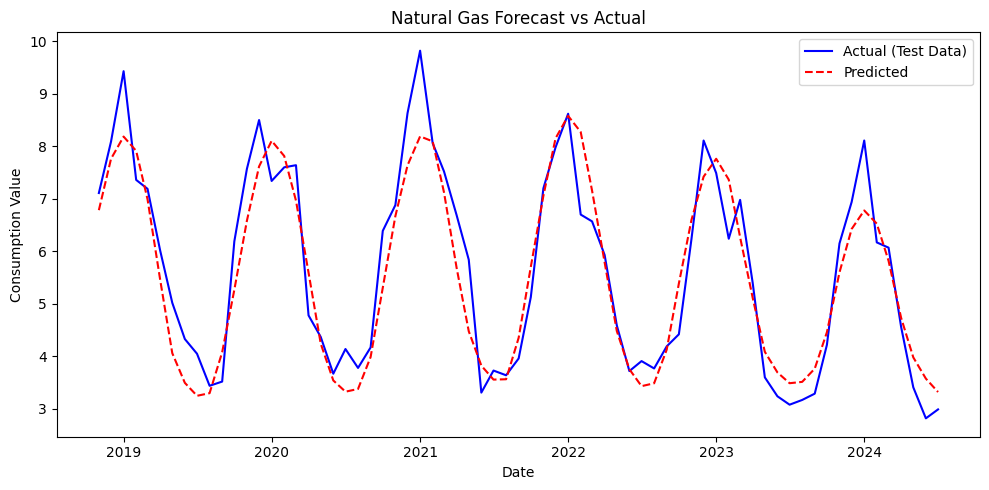

In [ ]:
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

seq_length = X.shape[1]
num_features = X.shape[2]
inputs = Input(shape=(seq_length, num_features))
lstm_out = LSTM(64, return_sequences=True)(inputs)
attention_out = MultiHeadAttention(num_heads=4, key_dim=64)(lstm_out, lstm_out)
attention_out = LayerNormalization()(lstm_out + attention_out)
attention_out = Dropout(0.2)(attention_out)
pooled = GlobalAveragePooling1D()(attention_out)
dense_out = Dense(32, activation='relu')(pooled)
outputs = Dense(1, activation='linear')(dense_out)

model = Model(inputs=inputs, outputs=outputs)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

history = model.fit(X_train, y_train, epochs=20, batch_size=16, validation_data=(X_test, y_test), verbose=0)

y_pred_scaled = model.predict(X_test, verbose=0)

y_test_full = np.zeros((len(y_test), scaled_df.shape[1]))
y_pred_full = np.zeros((len(y_pred_scaled), scaled_df.shape[1]))

y_test_full[:, target_idx] = y_test.flatten()
y_pred_full[:, target_idx] = y_pred_scaled.flatten()

y_test_rescaled = scaler.inverse_transform(y_test_full)[:, target_idx]
y_pred_rescaled = scaler.inverse_transform(y_pred_full)[:, target_idx]

test_dates = scaled_df.index[split_idx + seq_length:]

plt.figure(figsize=(10, 5))
plt.plot(test_dates, y_test_rescaled, label='Actual (Test Data)', color='blue')
plt.plot(test_dates, y_pred_rescaled, label='Predicted', color='red', linestyle='--')
plt.title('Natural Gas Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Consumption Value')
plt.legend()
plt.tight_layout()

In [17]:
mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
rmse = np.sqrt(mean_squared_error(y_test_rescaled, y_pred_rescaled))
mape = np.mean(np.abs((y_test_rescaled - y_pred_rescaled) / y_test_rescaled)) * 100
r2 = r2_score(y_test_rescaled, y_pred_rescaled)

metrics = {
    "MAE": round(mae, 3),
    "RMSE": round(rmse, 3),
    "MAPE (%)": round(mape, 2),
    "R-squared": round(r2, 3)
}
print(metrics)

{'MAE': 0.538, 'RMSE': np.float64(0.661), 'MAPE (%)': np.float64(9.91), 'R-squared': 0.874}


In [19]:
seq_len = X.shape[1]
num_feat = X.shape[2]

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    x = LayerNormalization(epsilon=1e-6)(inputs)
    x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
    x = Add()([x, inputs])
    
    res = x
    x = LayerNormalization(epsilon=1e-6)(x)
    x = Conv1D(filters=ff_dim, kernel_size=1, activation="relu")(x)
    x = Dropout(dropout)(x)
    x = Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
    return Add()([x, res])

inputs = Input(shape=(seq_len, num_feat))

x = Conv1D(filters=64, kernel_size=3, padding="same", activation="relu")(inputs)

for _ in range(2):
    x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)

x = GlobalAveragePooling1D(data_format="channels_first")(x)
x = Dense(64, activation="relu")(x)
x = Dropout(0.1)(x)
outputs = Dense(1)(x)

model = Model(inputs, outputs)

model.compile(optimizer=Adam(learning_rate=1e-3), loss=tf.keras.losses.Huber(), metrics=['mae'])

lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

model.fit(X_train, y_train, epochs=60, batch_size=16, validation_split=0.15, callbacks=[lr_scheduler, early_stop], verbose=0)

y_pred_scaled = model.predict(X_test, verbose=0)

y_test_full = np.zeros((len(y_test), scaled_df.shape[1]))
y_pred_full = np.zeros((len(y_pred_scaled), scaled_df.shape[1]))
y_test_full[:, target_idx] = y_test.flatten()
y_pred_full[:, target_idx] = y_pred_scaled.flatten()

y_test_res = scaler.inverse_transform(y_test_full)[:, target_idx]
y_pred_res = scaler.inverse_transform(y_pred_full)[:, target_idx]

mae = mean_absolute_error(y_test_res, y_pred_res)
rmse = np.sqrt(mean_squared_error(y_test_res, y_pred_res))
mape = np.mean(np.abs((y_test_res - y_pred_res) / y_test_res)) * 100
r2 = r2_score(y_test_res, y_pred_res)

print(f"MAE: {mae:.3f}, RMSE: {rmse:.3f}, MAPE: {mape:.2f}%, R2: {r2:.3f}")

I0000 00:00:1788804666.296244 1411534 service.cc:153] XLA service 0x77a47402f270 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1788804666.296271 1411534 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1788804666.407272 1411534 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1788804667.136826 1411534 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_23268__.65
I0000 00:00:1788804670.055735 1411534 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1788804676.125859 1411534 device_compiler.h:208] Compiled clu

MAE: 0.909, RMSE: 1.220, MAPE: 14.19%, R2: 0.572


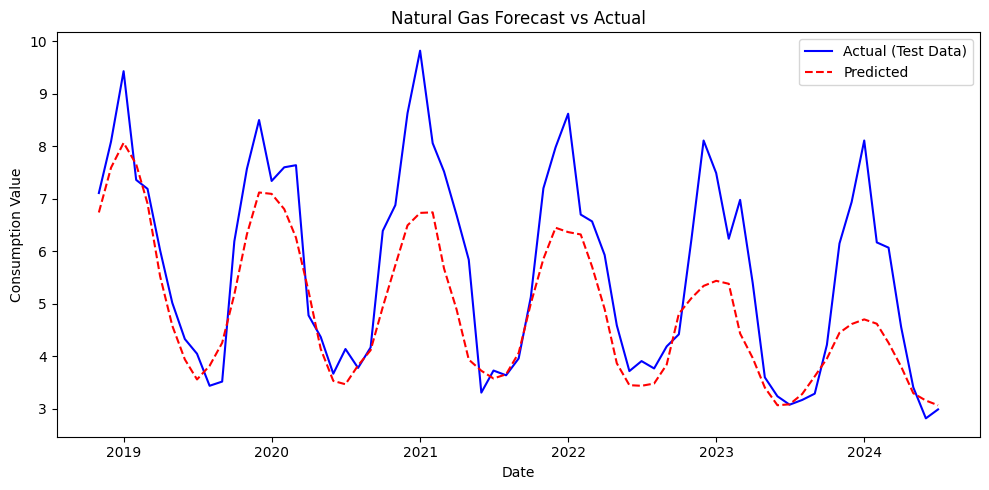

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(test_dates, y_test_res, label='Actual (Test Data)', color='blue')
plt.plot(test_dates, y_pred_res, label='Predicted', color='red', linestyle='--')
plt.title('Natural Gas Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Consumption Value')
plt.legend()
plt.tight_layout()